In [553]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc

In [554]:
with np.load('../specfem2d_examples/homotop/data_specfem_homotop.npz') as data:
    vx_specfem = data['vx']
    vz_specfem = data['vz']
    dt_specfem = data['dt']
with np.load('../devito_examples/homotop/data_devito_homotop.npz') as data:
    vx_devito = data['vx']
    vz_devito = data['vz']
    dt_devito = data['dt']

In [555]:
time_specfem = np.arange(vx_specfem.shape[0]) * dt_specfem
time_devito = np.arange(vx_devito.shape[0]) * dt_devito * 1e-3  # Convert ms to s

# Use time specfem as reference
# Interpolate Devito data to Specfem time grid using scipy interp
from scipy.interpolate import interp1d
time_shift = 0.019  # seconds
amplitude_scale_x = 4.31
amplitude_scale_z = 4.1
interp_vx = interp1d(time_devito+time_shift, vx_devito, axis=0, kind='cubic', fill_value='extrapolate')
interp_vz = interp1d(time_devito+time_shift, vz_devito, axis=0, kind='cubic', fill_value='extrapolate')
vx_devito_interp = interp_vx(time_specfem) * amplitude_scale_x * -1
vz_devito_interp = interp_vz(time_specfem) * amplitude_scale_z

In [556]:
#Shift devito data in time and scaling amplitude to better match specfem data
# time_shift = 0.01957  # seconds
# amplitude_scale = 4.2

# vx_devito_interp = np.roll(vx_devito_interp, int(time_shift / dt_specfem), axis=0) * amplitude_scale *-1
# vz_devito_interp = np.roll(vz_devito_interp, int(time_shift / dt_specfem), axis=0) * amplitude_scale

Text(0.5, 0, 'X (m)')

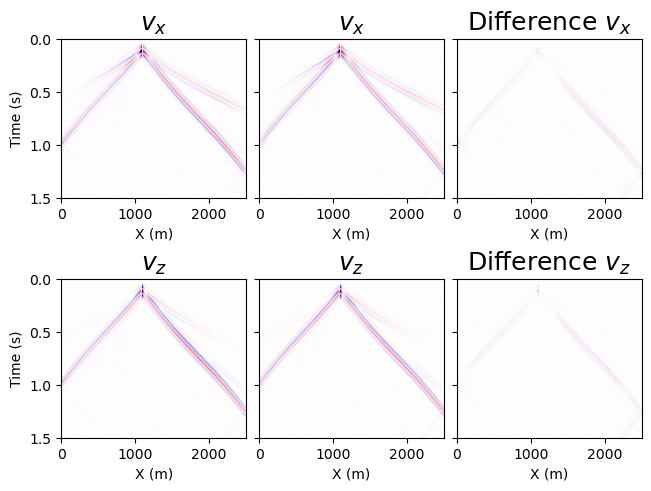

In [557]:
pcx=np.max(np.abs(vx_specfem))
pcz=np.max(np.abs(vz_specfem))
xmin=0
xmax=2500
from devitocurvilinear import odt_seismics
cmap = odt_seismics
cmap = 'seismic'
extent = [xmin, xmax, time_specfem[-1], time_specfem[0]]
fig1, ax = plt.subplots(2, 3, layout='constrained', sharey=True)
# VX
ax[0,0].set_title('$v_x$', fontsize=18)
ax[0,0].imshow(vx_devito_interp, cmap=cmap, vmin=-pcx, vmax=pcx, origin='upper', aspect='auto',
           extent=extent)
ax[0,0].set_ylabel('Time (s)')
ax[0,0].set_xlabel('X (m)')
ax[0,1].set_title('$v_x$', fontsize=18)
ax[0,1].imshow(vx_specfem, cmap=cmap, vmin=-pcx, vmax=pcx, origin='upper', aspect='auto',
           extent=extent)
ax[0,1].set_xlabel('X (m)')
ax[0,2].set_title('Difference $v_x$', fontsize=18)
im = ax[0,2].imshow(vx_devito_interp - vx_specfem, cmap=cmap, vmin=-pcx, vmax=pcx, origin='upper', aspect='auto',
           extent=extent)
ax[0,2].set_xlabel('X (m)')
# VZ
ax[1,0].set_title('$v_z$', fontsize=18)
ax[1,0].imshow(vz_devito_interp, cmap=cmap, vmin=-pcz, vmax=pcz, origin='upper', aspect='auto',
           extent=extent)
ax[1,0].set_ylabel('Time (s)')
ax[1,0].set_xlabel('X (m)')
ax[1,1].set_title('$v_z$', fontsize=18)
ax[1,1].imshow(vz_specfem, cmap=cmap, vmin=-pcz, vmax=pcz, origin='upper', aspect='auto',
           extent=extent)
ax[1,1].set_xlabel('X (m)')
ax[1,2].set_title('Difference $v_z$', fontsize=18)
im = ax[1,2].imshow(vz_devito_interp - vz_specfem, cmap=cmap, vmin=-pcz, vmax=pcz, origin='upper', aspect='auto',
           extent=extent)
ax[1,2].set_xlabel('X (m)')

In [558]:
norm_devito_vx = np.linalg.norm(vx_devito_interp)
norm_specfem_vx = np.linalg.norm(vx_specfem)
error_vx = np.linalg.norm(vx_devito_interp - vx_specfem) / norm_specfem_vx
norm_devito_vz = np.linalg.norm(vz_devito_interp)
norm_specfem_vz = np.linalg.norm(vz_specfem)
error_vz = np.linalg.norm(vz_devito_interp - vz_specfem) / norm_specfem_vz
print(f'Relative L2 error vx: {error_vx:.2%}')
print(f'Relative L2 error vz: {error_vz:.2%}')

Relative L2 error vx: 27.73%
Relative L2 error vz: 23.96%


In [559]:
np.linalg.norm(vz_devito_interp - vz_specfem)

np.float64(0.1996418651925581)

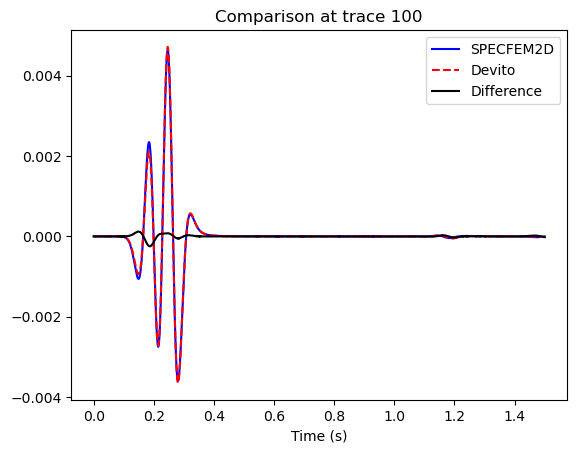

In [560]:
trace = 100
plt.plot(time_specfem, vx_specfem[:, trace], label='SPECFEM2D', color='blue')
plt.plot(time_specfem, vx_devito_interp[:, trace], label='Devito', color='red', linestyle='--')
plt.plot(time_specfem, vx_devito_interp[:, trace] - vx_specfem[:, trace], label='Difference', color='black', linestyle='-')
plt.xlabel('Time (s)')
plt.title(f'Comparison at trace {trace}')
plt.legend()
plt.show()

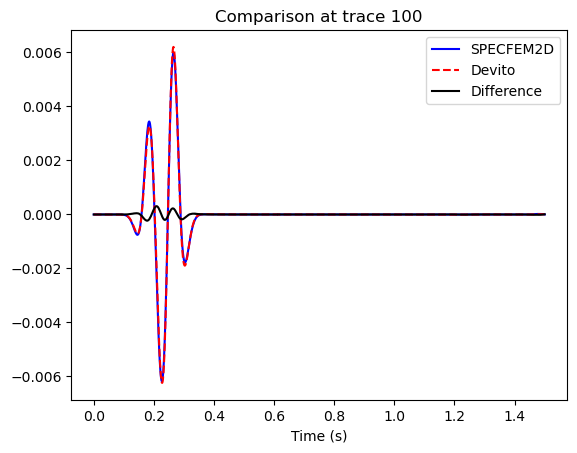

In [561]:
trace = 100
plt.plot(time_specfem, vz_specfem[:, trace], label='SPECFEM2D', color='blue')
plt.plot(time_specfem, vz_devito_interp[:, trace], label='Devito', color='red', linestyle='--')
plt.plot(time_specfem, vz_devito_interp[:, trace] - vz_specfem[:, trace], label='Difference', color='black', linestyle='-')
plt.xlabel('Time (s)')
plt.title(f'Comparison at trace {trace}')
plt.legend()
plt.show()

In [562]:
# L2 error in trace 100
trace = 100
l2_error_vx_trace100 = np.linalg.norm(vx_devito_interp[:, trace] - vx_specfem[:, trace]) / np.linalg.norm(vx_specfem[:, trace]) 
l2_error_vz_trace100 = np.linalg.norm(vz_devito_interp[:, trace] - vz_specfem[:, trace]) / np.linalg.norm(vz_specfem[:, trace])           
print(f'Relative L2 error vx at trace {trace}: {l2_error_vx_trace100:.2%}')
print(f'Relative L2 error vz at trace {trace}: {l2_error_vz_trace100:.2%}')

Relative L2 error vx at trace 100: 4.66%
Relative L2 error vz at trace 100: 4.79%


In [563]:
l2_error_vx_trace100

np.float64(0.04664375205770666)

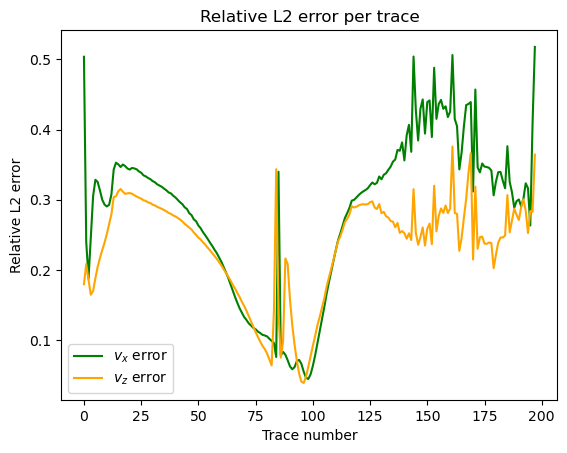

In [564]:
# L2 error per trace
l2_errors_vx = np.linalg.norm(vx_devito_interp - vx_specfem, axis=0) / np.linalg.norm(vx_specfem, axis=0)
l2_errors_vz = np.linalg.norm(vz_devito_interp - vz_specfem, axis=0) / np.linalg.norm(vz_specfem, axis=0)           
plt.plot(l2_errors_vx[3:], label='$v_x$ error', color='green')
plt.plot(l2_errors_vz[3:], label='$v_z$ error', color='orange')
plt.xlabel('Trace number')
plt.ylabel('Relative L2 error')
plt.title('Relative L2 error per trace')
plt.legend()